# Importacion de Librerias

In [38]:
# utilizado para la manipulación de directorios y rutas
import os

# Cálculo científico y vectorial para python
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from matplotlib import pyplot

# Modulo de optimizacion en scipy
from scipy import optimize
from sklearn.model_selection import train_test_split

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [39]:
df= pd.read_csv("test.csv")
df

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,19556,Female,Loyal Customer,52,Business travel,Eco,160,5,4,...,5,5,5,5,2,5,5,50,44.0,satisfied
1,1,90035,Female,Loyal Customer,36,Business travel,Business,2863,1,1,...,4,4,4,4,3,4,5,0,0.0,satisfied
2,2,12360,Male,disloyal Customer,20,Business travel,Eco,192,2,0,...,2,4,1,3,2,2,2,0,0.0,neutral or dissatisfied
3,3,77959,Male,Loyal Customer,44,Business travel,Business,3377,0,0,...,1,1,1,1,3,1,4,0,6.0,satisfied
4,4,36875,Female,Loyal Customer,49,Business travel,Eco,1182,2,3,...,2,2,2,2,4,2,4,0,20.0,satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25971,25971,78463,Male,disloyal Customer,34,Business travel,Business,526,3,3,...,4,3,2,4,4,5,4,0,0.0,neutral or dissatisfied
25972,25972,71167,Male,Loyal Customer,23,Business travel,Business,646,4,4,...,4,4,5,5,5,5,4,0,0.0,satisfied
25973,25973,37675,Female,Loyal Customer,17,Personal Travel,Eco,828,2,5,...,2,4,3,4,5,4,2,0,0.0,neutral or dissatisfied
25974,25974,90086,Male,Loyal Customer,14,Business travel,Business,1127,3,3,...,4,3,2,5,4,5,4,0,0.0,satisfied


# Creacion para una nueva Clasificacion

In [40]:
# 1. Crear una nueva columna para la clasificación multiclase
df['satisfaction_multiclass'] = df['satisfaction'].copy()

# Retraso significativo en llegada (>30 minutos)
high_delay = df['Arrival Delay in Minutes'] > 30

# Mal servicio (puntuación <= 2 en servicios clave)
poor_service = (
    (df['Inflight wifi service'] <= 2) |
    (df['Food and drink'] <= 2) |
    (df['Seat comfort'] <= 2) |
    (df['Inflight entertainment'] <= 2) |
    (df['Cleanliness'] <= 2)
)
# 3. Aplicar la nueva clasificación
# Si originalmente era "neutral or dissatisfied" Y (tiene retraso alto O mal servicio)
df.loc[(df['satisfaction'] == 'neutral or dissatisfied') & (high_delay | poor_service), 
       'satisfaction_multiclass'] = 'dissatisfied'

# 4. Clasificar como "neutral" los que no cumplen condiciones de insatisfacción
df.loc[(df['satisfaction'] == 'neutral or dissatisfied') & 
       (~high_delay & ~poor_service), 
       'satisfaction_multiclass'] = 'neutral'

# 5. Verificar la distribución de las nuevas clases
print("Distribución de clases original:")
print(df['satisfaction'].value_counts())
print("\nDistribución de clases multiclase:")
print(df['satisfaction_multiclass'].value_counts())

Distribución de clases original:
satisfaction
neutral or dissatisfied    14573
satisfied                  11403
Name: count, dtype: int64

Distribución de clases multiclase:
satisfaction_multiclass
dissatisfied    11637
satisfied       11403
neutral          2936
Name: count, dtype: int64


# Preprosesamiento

In [41]:
print('\nDATOS VACIOS')
print(pd.isnull(df).sum())


DATOS VACIOS
Unnamed: 0                            0
id                                    0
Gender                                0
Customer Type                         0
Age                                   0
Type of Travel                        0
Class                                 0
Flight Distance                       0
Inflight wifi service                 0
Departure/Arrival time convenient     0
Ease of Online booking                0
Gate location                         0
Food and drink                        0
Online boarding                       0
Seat comfort                          0
Inflight entertainment                0
On-board service                      0
Leg room service                      0
Baggage handling                      0
Checkin service                       0
Inflight service                      0
Cleanliness                           0
Departure Delay in Minutes            0
Arrival Delay in Minutes             83
satisfaction              

In [42]:
# Reemplazar '?' con NaN y eliminar filas
data = df.copy()
data = data.replace('?', np.nan)
rows_before = len(data)
data = data.dropna()
rows_after = len(data)
print(f"  Filas eliminadas: {rows_before - rows_after}")
print(f"  Filas restantes: {rows_after}")

  Filas eliminadas: 83
  Filas restantes: 25893


In [43]:
colum_i = ['Unnamed: 0', 'id','satisfaction']
data = data.drop(columns=colum_i, errors='ignore')
#print(data.head())

In [44]:
# a) Gender - Binary Encoding (2 categorías)
data['Gender'] = data['Gender'].map({'Female': 0, 'Male': 1})

# b) Customer Type - Binary Encoding (2 categorías)
data['Customer Type'] = data['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0})

# c) Type of Travel - Binary Encoding (2 categorías)
data['Type of Travel'] = data['Type of Travel'].map({'Business travel': 1, 'Personal Travel': 0})

# d) Class - Ordinal Encoding (tiene jerarquía: Business > Eco Plus > Eco)
class_mapping = {'Eco': 0, 'Eco Plus': 1, 'Business': 2}
data['Class'] = data['Class'].map(class_mapping)

# e) satisfaction (si aún existe) - Binary Encoding
if 'satisfaction' in data.columns:
    data['satisfaction'] = data['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

# f) satisfaction_multiclass (si la creaste) - Label Encoding para 3 clases
if 'satisfaction_multiclass' in data.columns:
    le = LabelEncoder()
    data['satisfaction_multiclass'] = le.fit_transform(data['satisfaction_multiclass'])
    print("Mapping para satisfaction_multiclass:")
    for i, class_name in enumerate(le.classes_):
        print(f"  {class_name}: {i}")

print(data.head())

Mapping para satisfaction_multiclass:
  dissatisfied: 0
  neutral: 1
  satisfied: 2
   Gender  Customer Type  Age  Type of Travel  Class  Flight Distance  \
0       0              1   52               1      0              160   
1       0              1   36               1      2             2863   
2       1              0   20               1      0              192   
3       1              1   44               1      2             3377   
4       0              1   49               1      0             1182   

   Inflight wifi service  Departure/Arrival time convenient  \
0                      5                                  4   
1                      1                                  1   
2                      2                                  0   
3                      0                                  0   
4                      2                                  3   

   Ease of Online booking  Gate location  ...  Inflight entertainment  \
0                       3

# Seleccion de "X" y "y"

In [45]:
# Separar características y etiquetas
X = data.drop('satisfaction_multiclass', axis=1).values
y = data['satisfaction_multiclass'].values
print(X)
print(y)

[[ 0.  1. 52. ...  5. 50. 44.]
 [ 0.  1. 36. ...  5.  0.  0.]
 [ 1.  0. 20. ...  2.  0.  0.]
 ...
 [ 0.  1. 17. ...  2.  0.  0.]
 [ 1.  1. 14. ...  4.  0.  0.]
 [ 0.  1. 42. ...  1.  0.  0.]]
[2 2 0 ... 0 2 0]


In [46]:
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [47]:
X_norm, mu, sigma = featureNormalize(X)

In [48]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agraga el termino de intercepción a A
# X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)
X = X_norm
#X = np.concatenate([np.ones((m, 1)), X], axis=1)
# Asumiendo que X es un arreglo de NumPy
filas, columnas = X.shape
print(f"La cantidad de columnas es: {columnas}")
print(f"La cantidad de filas es: {filas}")

La cantidad de columnas es: 22
La cantidad de filas es: 25893


# Division del dataset 80% y 20%

In [50]:
# Dividiendo los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

m = y_train.size

# Mostramos los datos que seran para el entrenamiento
print("Datos de X_train:")
print(X_train)
print("Datos de y_train:")
print(y_train)

# Mostramos la cantidad de ejemplos que tienen X_train y y_train
print('-' * 80)
print("El 80% de ejemplos que seran para el entrenamiento son: {:.0f}".format(len(X_train)))
print("El 20% de ejemplos que seran para el test son: {:.0f}".format(len(X_test)))

Datos de X_train:
[[ 1.01404055  0.475938   -0.23932861 ... -0.21641385 -0.38254681
  -0.1530209 ]
 [-0.98615386  0.475938   -0.7018654  ... -1.73233537 -0.38254681
  -0.39291334]
 [ 1.01404055  0.475938   -0.90009545 ... -0.21641385 -0.38254681
  -0.39291334]
 ...
 [ 1.01404055 -2.101114   -1.09832551 ... -0.97437461  0.07462431
  -0.12636618]
 [ 1.01404055  0.475938    0.42143823 ...  0.54154691  0.66625751
   0.08687154]
 [ 1.01404055  0.475938    1.21435844 ... -0.97437461 -0.38254681
  -0.39291334]]
Datos de y_train:
[1 0 2 ... 0 0 0]
--------------------------------------------------------------------------------
El 80% de ejemplos que seran para el entrenamiento son: 20714
El 20% de ejemplos que seran para el test son: 5179


In [51]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

In [52]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [53]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

In [54]:
def lrCostFunction(theta, X, y, lambda_):
#     alpha = 0.003
#     theta = theta.copy()
    # Inicializa algunos valores utiles
    m = y.size

    # convierte las etiquetas a valores enteros si son boleanos
    if y.dtype == bool:
        y = y.astype(int)

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    temp = theta
    temp[0] = 0

#     J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
#     theta = theta - (alpha / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad
#    return J, theta

In [55]:
def OneVsAll(X, y, num_labels, lambda_):
    alpha = 0.03  # Aumentada para convergencia más rápida
    num_iters = 2000  # Reducidas las iteraciones

    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    
    # Agrega unos a la matriz X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    
    # Prepara la gráfica solo una vez
    pyplot.figure(figsize=(10, 6))
    
    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        y_actual = np.where(y == c, 1, 0)
        
        theta, J_history = descensoGradiente(initial_theta, X, y_actual, alpha, num_iters)
        
        all_theta[c] = theta
        # Grafica la convergencia para esta clase
        pyplot.plot(np.arange(len(J_history)), J_history, lw=1, label=f'Clase {c}')
    
    # Muestra todas las gráficas juntas al final
    pyplot.xlabel('Número de iteraciones')
    pyplot.ylabel('Costo J')
    pyplot.legend()
    pyplot.title('Convergencia del costo para todas las clases')
    pyplot.show()
    
    return all_theta

In [56]:
def OneVsAllOM(X, y, num_labels, lambda_):

    # algunas variables utiles
    m, n = X.shape

    all_theta = np.zeros((num_labels, n + 1))

    # Agrega unos a la matriz X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 10}
        res = optimize.minimize(lrCostFunction,
                                initial_theta,
                                (X, (y == c), lambda_),
                                jac=True,
                                method='CG',
                                options=options)

        all_theta[c] = res.x


    return all_theta

# Entrenamiento

In [57]:
# La entrada es de 14 elemento contando con x0
input_layer_size  = 23

# 10 etiquetas, de 1 a 10 (tomar en cuenta que se asigna "0" a la etiqueta 10)
num_labels = 3
m = y.size

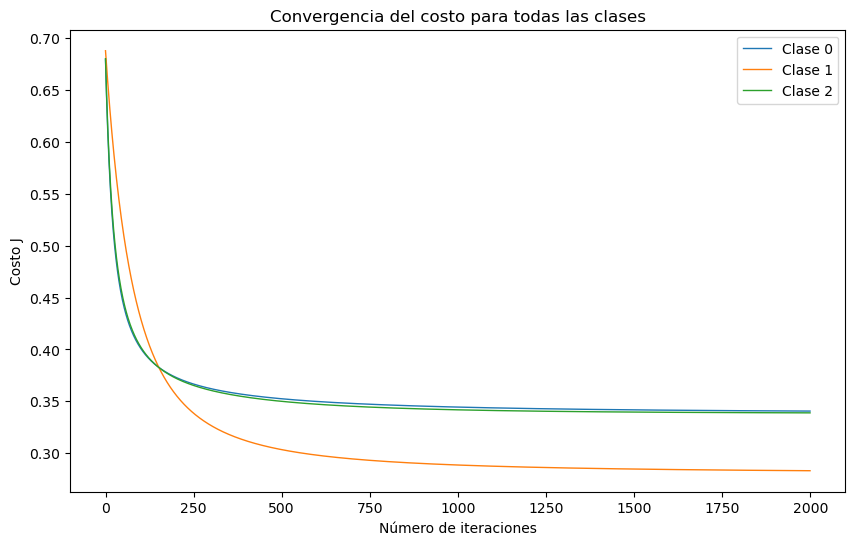

(3, 23)


In [58]:
lambda_ = 0.1
all_theta = OneVsAll(X_train, y_train, num_labels, lambda_)
print(all_theta.shape)

In [59]:
print(all_theta)

[[-0.46758937 -0.14893939 -0.61711103  0.24268788 -0.93230933 -0.19426285
  -0.01322841 -0.91426592  0.27390444  0.10164752  0.10953344 -0.17042782
  -0.69790024 -0.28172005 -0.26519465 -0.11620332 -0.28975806 -0.16205415
  -0.24600045 -0.21056542 -0.41958343  0.17662122  0.34637236]
 [-2.53512828  0.04928753 -0.27932987 -0.1501027  -0.3845619  -0.26446449
  -0.08086584  0.47046017  0.02505161  0.31878639 -0.18871658  0.31848981
  -0.19568839  0.19472073  0.12052047 -0.2096023  -0.09462487  0.03273975
  -0.19696536  0.06843741  0.13770005 -0.34440247 -0.42935673]
 [-0.46566108  0.07664822  0.71257435 -0.10692     1.15865432  0.34007464
   0.02180538  0.51032027 -0.27799568 -0.1596299  -0.0149108  -0.04080226
   0.78921882  0.09779058  0.13093446  0.33041013  0.34669853  0.12505257
   0.41278981  0.15521825  0.27782497 -0.06008231 -0.14803517]]


In [60]:
all_theta2 = OneVsAllOM(X_train, y_train, num_labels, lambda_)
print(all_theta.shape)

(3, 23)


In [61]:
print(all_theta2)

[[-0.51307081 -0.16198794 -0.6882982   0.25771687 -1.04361104 -0.13813279
  -0.01331938 -1.08169501  0.24742041  0.27502491  0.08640283 -0.17960667
  -0.71642238 -0.28518054 -0.17291884 -0.13176853 -0.30609194 -0.16998668
  -0.24405187 -0.23837161 -0.48336004  0.1178981   0.42139625]
 [-2.76728048  0.04922282 -0.32669577 -0.14716616 -0.4598641  -0.25079852
  -0.06454664  0.61071314  0.01377029  0.36868843 -0.22764168  0.39913278
  -0.33289628  0.25858554  0.0671947  -0.22550214 -0.11650098  0.04214775
  -0.21657659  0.0879192   0.12018072 -0.49851401 -0.66331001]
 [-0.47568612  0.07702915  0.77497153 -0.12868526  1.27417036  0.28602901
   0.00912907  0.55273074 -0.2594479  -0.23175058  0.00660954 -0.03442042
   0.82031737  0.07818011  0.05330257  0.35854739  0.35734521  0.13763241
   0.42630099  0.17894372  0.33652407 -0.03681421 -0.18811467]]


# Evaluacion 

In [62]:
def predictOneVsAll(all_theta, X):
    m = X.shape[0];
    num_labels = all_theta.shape[0]

    p = np.zeros(m)

    # Add ones to the X data matrix
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis = 1)

    return p

In [63]:
print(X_test.shape)
#X_test = np.concatenate([np.ones((X_test.shape[0], 1)), X_test], axis=1)
pred1 = predictOneVsAll(all_theta, X_test)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred1 == y_test) * 100))
pred2 = predictOneVsAll(all_theta2, X_test)
print('Precision del conjuto de entrenamiento: {:.2f}%'.format(np.mean(pred2 == y_test) * 100))


(5179, 22)
Precision del conjuto de entrenamiento: 80.85%
Precision del conjuto de entrenamiento: 80.96%
